In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as sci
import statsmodels.api as sm

## Read the Data

In [60]:
dataframe_QB = pd.read_excel("../Performance_data1.xltx", sheet_name="QB")
dataframe_RB = pd.read_excel("../Performance_data1.xltx", sheet_name="RB")
dataframe_WR = pd.read_excel("../Performance_data1.xltx", sheet_name="WR")

dataframe_QB_carrer_earnings = pd.read_excel("../career_earnings_QB.xltx")
dataframe_RB_carrer_earnings = pd.read_excel("../career_earnings_RB.xltx")
dataframe_WR_carrer_earnings = pd.read_excel("../career_earnings_WR.xltx")

In [61]:
dataframe_QB = dataframe_QB.merge(dataframe_QB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_RB = dataframe_RB.merge(dataframe_RB_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")
dataframe_WR = dataframe_WR.merge(dataframe_WR_carrer_earnings[['Player', 'Cap-Inflated Earnings']], on="Player", how="left")

In [62]:
dataframe_QB_carrer_earnings

,Player,Years Active,Career Earnings,Cap-Inflated Earnings,Earnings By Team
0,Matt Stafford,2009‑,"$408,000,000","$688,913,746","Lions: $219,000,000\t\t\t\t\t\t\tRams: $189,00..."
1,Aaron Rodgers,2005‑,"$395,812,794","$704,306,889","Packers: $306,642,206\t\t\t\t\t\t\tJets: $75,0..."
2,Kirk Cousins,2012‑,"$331,469,288","$483,788,276","Vikings: $185,000,000\t\t\t\t\t\t\tFalcons: $1..."
3,Tom Brady,2000‑2022,"$317,619,794","$708,165,480","Patriots: $230,324,206\t\t\t\t\t\t\tBuccaneers..."
4,Russell Wilson,2012‑2025,"$315,840,123","$493,002,295","Seahawks: $181,340,123\t\t\t\t\t\t\tBroncos: $..."
...,...,...,...,...,...
428,Brogan Roback,9999‑0,"$1,000","$1,700","Browns: $1,000"
429,Tommy Rees,9999‑0,"$1,000","$2,265","Commanders: $1,000"
430,Travis Partridge,9999‑0,"$1,000","$2,265","Vikings: $1,000"
431,Nick Stevens,9999‑0,$500,$850,Broncos: $500


## Transfrom the Data

In [63]:
#dataframe_QB['Performance-Index'] = (dataframe_QB['Yds'] /  dataframe_QB['Yds'].max()) * 50 + (dataframe_QB['TD'] /  dataframe_QB['TD'].max()) * 50
#dataframe_RB['Performance-Index'] = (dataframe_RB['Yds'] /  dataframe_RB['Yds'].max()) * 50 + (dataframe_RB['TD'] /  dataframe_RB['TD'].max()) * 50
#dataframe_WR['Performance-Index'] = (dataframe_WR['Yds'] /  dataframe_WR['Yds'].max()) * 50 + (dataframe_WR['TD'] /  dataframe_WR['TD'].max()) * 50

In [64]:
dataframe_QB['Performance-Index'] =  sci.zscore(dataframe_QB['Yds']) + sci.zscore(dataframe_QB['TD'])
dataframe_RB['Performance-Index'] =  sci.zscore(dataframe_RB['Yds']) + sci.zscore(dataframe_RB['TD'])
dataframe_WR['Performance-Index'] =  sci.zscore(dataframe_WR['Yds']) + sci.zscore(dataframe_WR['TD'])

In [65]:
dataframe_QB

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Tom Brady,89214,6,199,2000,2022,649,QB,23,"$708,165,480",11.183189
1,2,Drew Brees,80358,2,32,2001,2020,571,QB,20,"$606,300,629",9.821619
2,3,Aaron Rodgers,66274,1,24,2005,2025,527,QB,21,"$704,306,889",8.445486
3,4,Matthew Stafford,64516,1,1,2009,2025,423,QB,17,NaN,7.302469
4,5,Ben Roethlisberger,64088,1,11,2004,2021,418,QB,18,"$559,659,879",7.224535
...,...,...,...,...,...,...,...,...,...,...,...,...
248,249,Reggie McNeal,0,6,193,2006,2006,0,QB,1,NaN,-1.184670
249,250,Jalen Milroe,0,3,92,2025,2025,0,QB,1,"$2,196,106",-1.184670
250,251,Brad Smith,0,4,103,2006,2012,0,WR/QB,7,NaN,-1.184670
251,252,Tommy Stevens,0,7,240,2020,2020,0,QB,1,"$368,482",-1.184670


In [66]:
dataframe_RB

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Frank Gore,16000,3,65,2005,2020,81,RB,16,"$147,956,622",9.422983
1,2,Adrian Peterson,14918,1,7,2007,2021,120,RB,15,"$236,878,277",11.023912
2,3,LaDainian Tomlinson,13684,1,5,2001,2011,145,RB,11,"$198,128,079",11.831344
3,4,Derrick Henry,13018,2,45,2016,2025,122,RB,10,"$114,373,896",10.359195
4,5,Steven Jackson,11438,1,24,2004,2015,69,RB,12,"$135,785,882",6.948511
...,...,...,...,...,...,...,...,...,...,...,...,...
568,567,Jeremy Ware,0,7,215,2010,2010,0,FB,1,NaN,-1.290046
569,568,Marquez Williams,0,7,240,2017,2017,0,FB,1,NaN,-1.290046
570,569,Brandon Wilson,0,6,207,2017,2021,0,RB,5,NaN,-1.290046
571,570,Chris Massey,-1,7,243,2002,2011,0,RB,10,NaN,-1.290451


In [67]:
dataframe_WR

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Larry Fitzgerald,17492,1,3,2004,2020,121,WR,17,"$425,891,097",11.677102
1,2,Steve Smith Sr.,14731,3,74,2001,2016,81,WR,16,"$220,148,783",8.471684
2,3,Reggie Wayne,14345,1,30,2001,2014,82,WR,14,"$177,715,590",8.387644
3,4,Andre Johnson,14185,1,3,2003,2016,70,WR,14,"$284,682,356",7.667145
4,5,Anquan Boldin,13779,2,54,2003,2016,82,WR,14,"$169,868,936",8.183427
...,...,...,...,...,...,...,...,...,...,...,...,...
785,770,Ricky White,0,7,238,2025,2025,0,WR,1,"$446,658",-1.317050
786,771,Avery Williams,0,5,183,2025,2025,0,WR,1,NaN,-1.317050
787,772,Brandon Williams,0,3,84,2006,2007,0,WR,2,NaN,-1.317050
788,773,Harry Williams,0,7,240,2005,2007,0,WR,3,NaN,-1.317050


In [68]:
dataframe_RB['Pos'] = np.where(dataframe_RB['Pos'] =='FB', 'RB', 'RB')

In [69]:
dataframe_RB

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Frank Gore,16000,3,65,2005,2020,81,RB,16,"$147,956,622",9.422983
1,2,Adrian Peterson,14918,1,7,2007,2021,120,RB,15,"$236,878,277",11.023912
2,3,LaDainian Tomlinson,13684,1,5,2001,2011,145,RB,11,"$198,128,079",11.831344
3,4,Derrick Henry,13018,2,45,2016,2025,122,RB,10,"$114,373,896",10.359195
4,5,Steven Jackson,11438,1,24,2004,2015,69,RB,12,"$135,785,882",6.948511
...,...,...,...,...,...,...,...,...,...,...,...,...
568,567,Jeremy Ware,0,7,215,2010,2010,0,RB,1,NaN,-1.290046
569,568,Marquez Williams,0,7,240,2017,2017,0,RB,1,NaN,-1.290046
570,569,Brandon Wilson,0,6,207,2017,2021,0,RB,5,NaN,-1.290046
571,570,Chris Massey,-1,7,243,2002,2011,0,RB,10,NaN,-1.290451


In [134]:
joined_datas = pd.concat([dataframe_QB, dataframe_RB, dataframe_WR])

joined_datas["Cap-Inflated Earnings"] = joined_datas["Cap-Inflated Earnings"].str.replace("$", "", regex=False)\
                           .str.replace(",", "", regex=False)\
                           .astype(float)


In [135]:
joined_datas

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Tom Brady,89214,6,199,2000,2022,649,QB,23,708165480.0,11.183189
1,2,Drew Brees,80358,2,32,2001,2020,571,QB,20,606300629.0,9.821619
2,3,Aaron Rodgers,66274,1,24,2005,2025,527,QB,21,704306889.0,8.445486
3,4,Matthew Stafford,64516,1,1,2009,2025,423,QB,17,NaN,7.302469
4,5,Ben Roethlisberger,64088,1,11,2004,2021,418,QB,18,559659879.0,7.224535
...,...,...,...,...,...,...,...,...,...,...,...,...
785,770,Ricky White,0,7,238,2025,2025,0,WR,1,446658.0,-1.317050
786,771,Avery Williams,0,5,183,2025,2025,0,WR,1,NaN,-1.317050
787,772,Brandon Williams,0,3,84,2006,2007,0,WR,2,NaN,-1.317050
788,773,Harry Williams,0,7,240,2005,2007,0,WR,3,NaN,-1.317050


In [136]:
joined_datas = joined_datas.dropna(axis=0)

In [137]:
joined_datas

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Tom Brady,89214,6,199,2000,2022,649,QB,23,708165480.0,11.183189
1,2,Drew Brees,80358,2,32,2001,2020,571,QB,20,606300629.0,9.821619
2,3,Aaron Rodgers,66274,1,24,2005,2025,527,QB,21,704306889.0,8.445486
4,5,Ben Roethlisberger,64088,1,11,2004,2021,418,QB,18,559659879.0,7.224535
5,6,Philip Rivers,63984,1,4,2004,2025,425,QB,22,536563033.0,7.286594
...,...,...,...,...,...,...,...,...,...,...,...,...
778,763,Evan Spencer,0,6,187,2015,2015,0,WR,1,567418.0,-1.317050
779,764,Marquez Stevenson,0,6,203,2021,2021,0,WR,1,1735182.0,-1.317050
780,765,Tommy Streeter,0,6,198,2014,2014,0,WR,1,1588492.0,-1.317050
783,768,LaJohntay Wester,0,6,203,2025,2025,0,WR,1,1137988.0,-1.317050


In [138]:
joined_datas['Cap-Inflated Earnings']

0      708165480.0
1      606300629.0
2      704306889.0
4      559659879.0
5      536563033.0
          ...     
778       567418.0
779      1735182.0
780      1588492.0
783      1137988.0
785       446658.0
Name: Cap-Inflated Earnings, Length: 1069, dtype: float64

In [139]:
joined_datas['Cap-Inflated Earnings'] = sci.zscore(joined_datas['Cap-Inflated Earnings'])

C:\Users\nikla\AppData\Local\Temp\ipykernel_7008\2222077537.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_datas['Cap-Inflated Earnings'] = sci.zscore(joined_datas['Cap-Inflated Earnings'])


In [140]:
joined_datas['Cap-Inflated Earnings']

0      8.404547
1      7.124713
2      8.356068
4      6.538717
5      6.248527
         ...   
778   -0.485745
779   -0.471073
780   -0.472916
783   -0.478576
785   -0.487262
Name: Cap-Inflated Earnings, Length: 1069, dtype: float64

In [142]:
joined_datas['Pick'] = joined_datas['Pick'].max() - joined_datas['Pick']

C:\Users\nikla\AppData\Local\Temp\ipykernel_7008\844243382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joined_datas['Pick'] = joined_datas['Pick'].max() - joined_datas['Pick']


In [143]:
joined_datas

,Rk,Player,Yds,Round,Pick,From,To,TD,Pos,Seasons in the NFL,Cap-Inflated Earnings,Performance-Index
0,1,Tom Brady,89214,6,63,2000,2022,649,QB,23,8.404547,11.183189
1,2,Drew Brees,80358,2,230,2001,2020,571,QB,20,7.124713,9.821619
2,3,Aaron Rodgers,66274,1,238,2005,2025,527,QB,21,8.356068,8.445486
4,5,Ben Roethlisberger,64088,1,251,2004,2021,418,QB,18,6.538717,7.224535
5,6,Philip Rivers,63984,1,258,2004,2025,425,QB,22,6.248527,7.286594
...,...,...,...,...,...,...,...,...,...,...,...,...
778,763,Evan Spencer,0,6,75,2015,2015,0,WR,1,-0.485745,-1.317050
779,764,Marquez Stevenson,0,6,59,2021,2021,0,WR,1,-0.471073,-1.317050
780,765,Tommy Streeter,0,6,64,2014,2014,0,WR,1,-0.472916,-1.317050
783,768,LaJohntay Wester,0,6,59,2025,2025,0,WR,1,-0.478576,-1.317050


## Plot the data

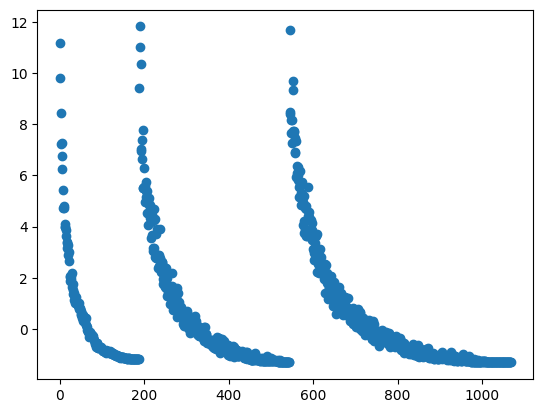

In [144]:
plt.scatter(np.arange(len(joined_datas['Performance-Index'])), joined_datas['Performance-Index'])

Text(0, 0.5, 'Performance Index')

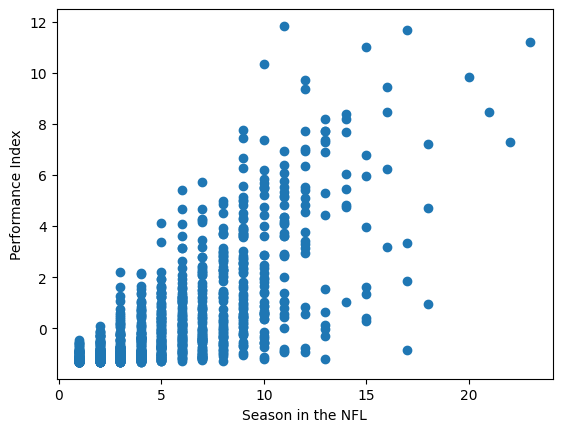

In [145]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Performance-Index'])
plt.xlabel("Season in the NFL")
plt.ylabel("Performance Index")

Text(0, 0.5, 'Cap-Inflated Earnings')

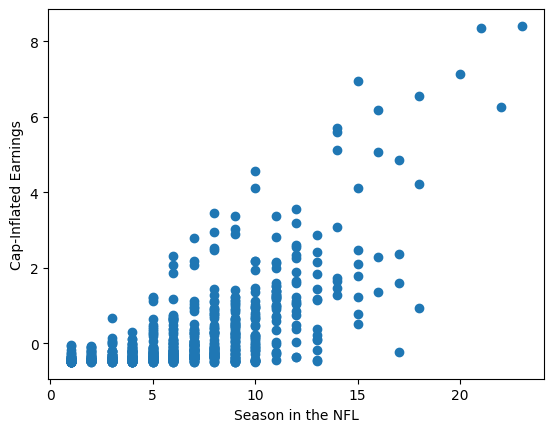

In [146]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("Season in the NFL")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Cap-Inflated Earnings')

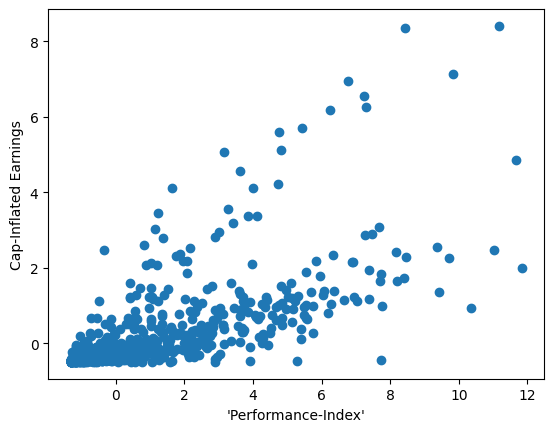

In [147]:
plt.scatter(joined_datas['Performance-Index'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("'Performance-Index'")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Cap-Inflated Earnings')

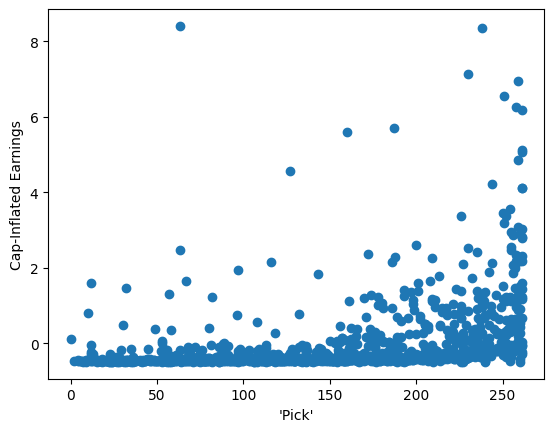

In [148]:
plt.scatter(joined_datas['Pick'], joined_datas['Cap-Inflated Earnings'])
plt.xlabel("'Pick'")
plt.ylabel('Cap-Inflated Earnings')

Text(0, 0.5, 'Performance-Index')

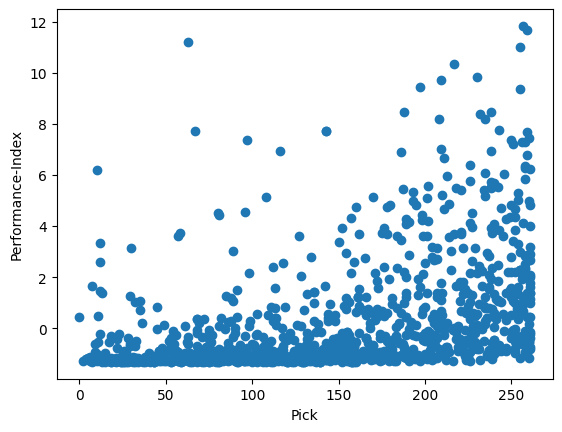

In [149]:
plt.scatter(joined_datas['Pick'], joined_datas['Performance-Index'])
plt.xlabel('Pick')
plt.ylabel('Performance-Index')

Text(0, 0.5, 'Pick')

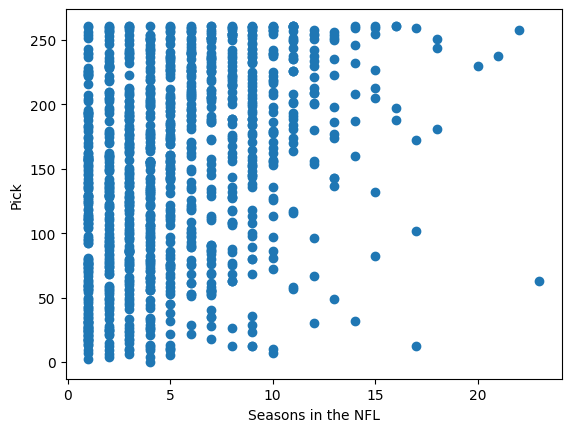

In [150]:
plt.scatter(joined_datas['Seasons in the NFL'], joined_datas['Pick'])
plt.xlabel('Seasons in the NFL')
plt.ylabel('Pick')

<Axes: xlabel='Round', ylabel='count'>

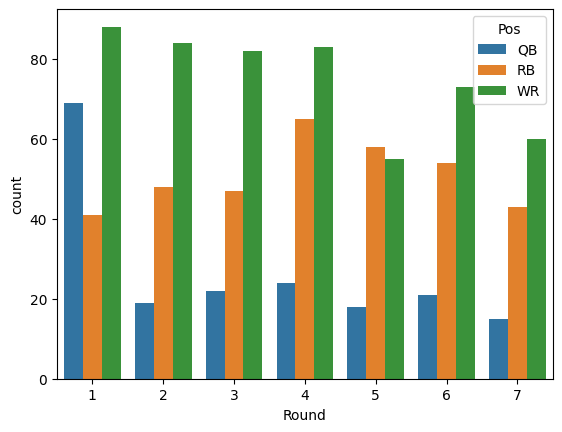

In [151]:
sns.countplot(x="Round", hue="Pos", data=joined_datas)

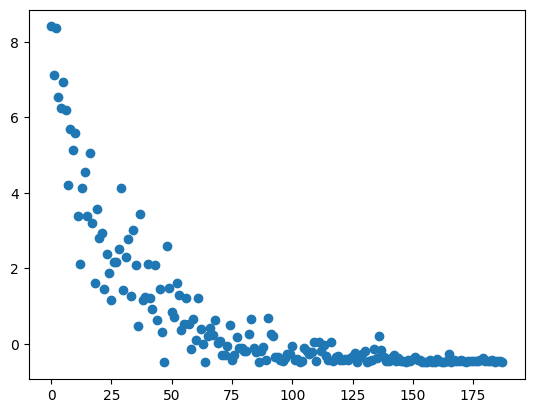

In [152]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "QB"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "QB"]['Cap-Inflated Earnings'])

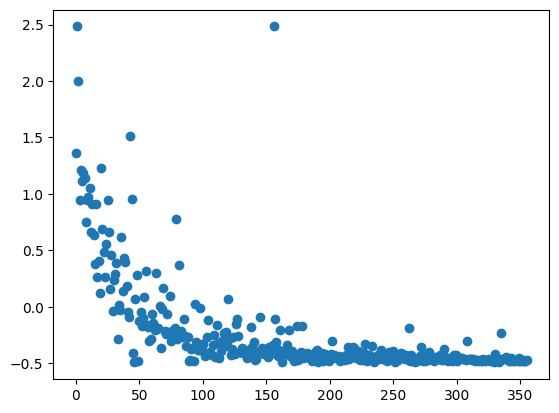

In [153]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "RB"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "RB"]['Cap-Inflated Earnings'])

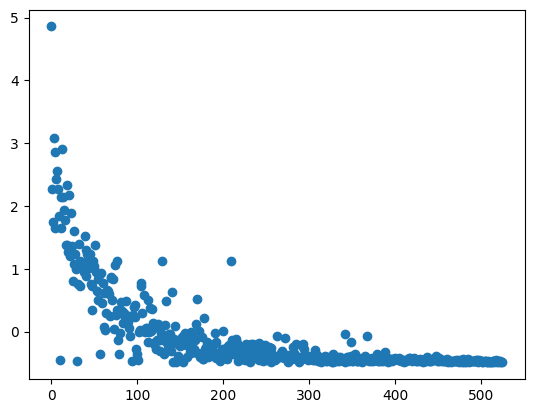

In [154]:
plt.scatter(np.arange(len(joined_datas[joined_datas["Pos"] == "WR"]['Cap-Inflated Earnings'])), joined_datas[joined_datas["Pos"] == "WR"]['Cap-Inflated Earnings'])

<Axes: xlabel='Pos', ylabel='Performance-Index'>

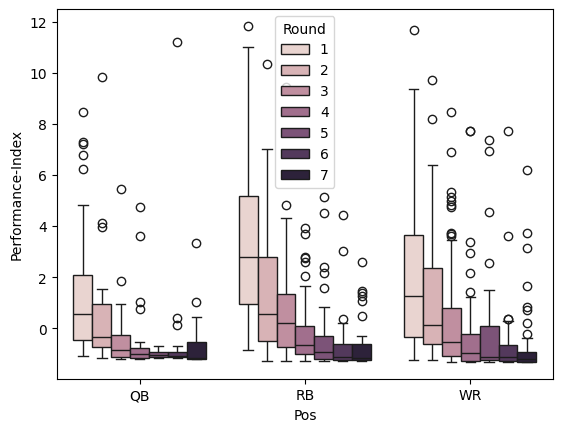

In [155]:
sns.boxplot(data=joined_datas, x='Pos', y='Performance-Index', hue="Round")

<Axes: xlabel='Pos', ylabel='Cap-Inflated Earnings'>

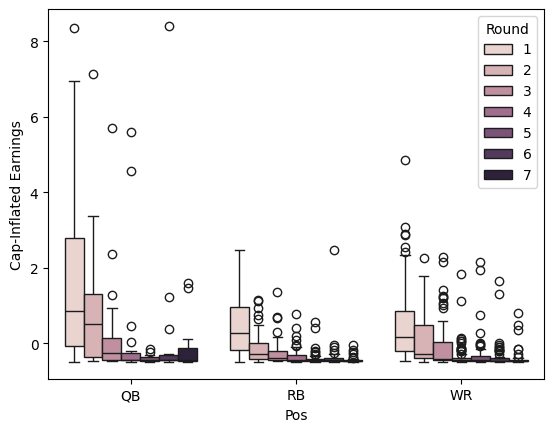

In [156]:
sns.boxplot(data=joined_datas, x='Pos', y='Cap-Inflated Earnings', hue="Round")

In [157]:
import statsmodels.formula.api as smf
X = joined_datas[['Pos', 'Round', 'Seasons in the NFL']]
y = joined_datas['Cap-Inflated Earnings']

X = pd.get_dummies(X, columns=['Pos', 'Round'], dtype=int)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()
#model = smf.ols(formula="Pos ~ Round", data=).fit()

# View the results
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Cap-Inflated Earnings   R-squared:                       0.562
Model:                               OLS   Adj. R-squared:                  0.559
Method:                    Least Squares   F-statistic:                     151.2
Date:                   Thu, 02 Jul 2026   Prob (F-statistic):          4.10e-183
Time:                           11:48:09   Log-Likelihood:                -1075.2
No. Observations:                   1069   AIC:                             2170.
Df Residuals:                       1059   BIC:                             2220.
Df Model:                              9                                         
Covariance Type:               nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const 

In [86]:
model.params

const                -0.549868
Seasons in the NFL    0.161593
Pos_QB                0.135017
Pos_RB               -0.388067
Pos_WR               -0.296818
Round_1               0.395223
Round_2              -0.076096
Round_3              -0.179808
Round_4              -0.192111
Round_5              -0.212272
Round_6              -0.155308
Round_7              -0.129496
dtype: float64

Manuelles Pos_code Mapping:
  QB -> 2
  RB -> 0
  WR -> 1
N=1069


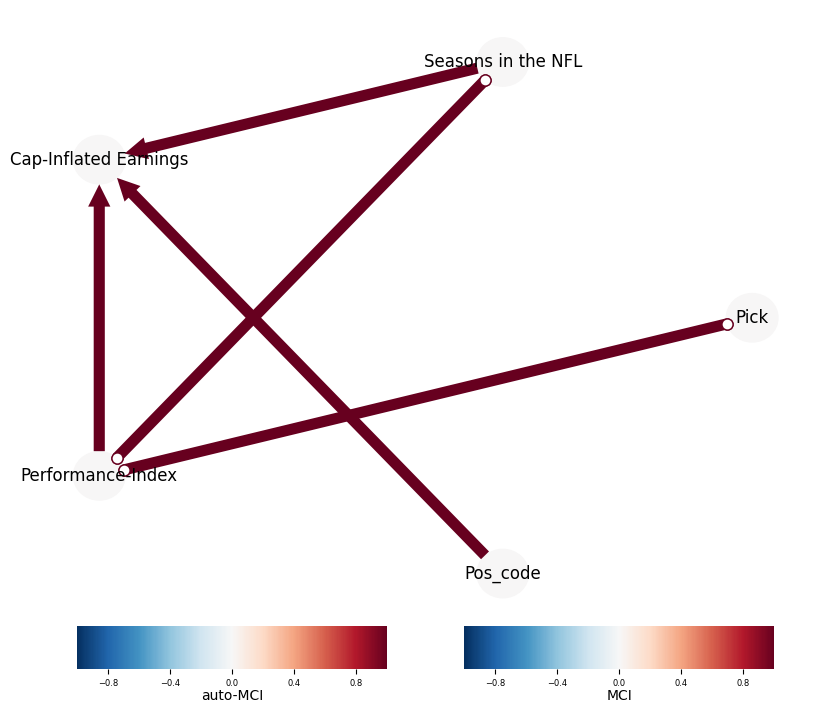

In [158]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.regressionCI import RegressionCI
from tigramite import plotting as tp

# 1. 'Round' zu den ausgewählten Spalten hinzufügen
selected_columns = [
    'Pick', 
    'Pos', 
    'Seasons in the NFL', 
    'Cap-Inflated Earnings', 
    'Performance-Index'
]

df_filtered = joined_datas[selected_columns].dropna().copy()
df_model = df_filtered.copy()

# 2. Manuelles Mapping für die kategoriale Variable 'Pos'
custom_pos_mapping = {
    'QB': 2,
    'RB': 0,
    'WR': 1
}
df_model['Pos_code'] = df_model['Pos'].map(custom_pos_mapping)

print("Manuelles Pos_code Mapping:")
for pos, code in custom_pos_mapping.items():
    print(f"  {pos} -> {code}")

df_model = df_model.drop(columns=['Pos'])
var_names = df_model.columns.tolist()
 
print(f"N={len(df_model)}")
 
data_array = df_model.values.astype(float)

# 3. Data-Type Matrix definieren
data_type_matrix = np.zeros(data_array.shape, dtype='int')

# 'Pos_code' ist rein kategorial/nominal (Wert = 1)
data_type_matrix[:, var_names.index('Pos_code')] = 1

# 'Round' bleibt bei 0 (kontinuierlich/ordinal), da RegressionCI 
# die lineare Rangfolge von Runde 1 bis 7 direkt interpretieren kann.

tigramite_df = dp.DataFrame(
    data_array,
    data_type=data_type_matrix,
    var_names=var_names
)
 
regressionCI = RegressionCI(significance='analytic')
pcmci = PCMCI(dataframe=tigramite_df, cond_ind_test=regressionCI, verbosity=0)
results = pcmci.run_pcalg_non_timeseries_data(pc_alpha=0.05)

tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    figsize=(10, 8),
    node_size=0.18,
    node_label_size=12,
    link_colorbar_label='MCI',
    node_colorbar_label='auto-MCI',
)
plt.show()